# Лабораторная работа №1.1
## Статистический анализ и продвинутая визуализация

**Датасет:** Музеи мира (world_museums_complete.csv)

**Выполнила:** Рустамова Азиза

---

## Содержание
1. Типы признаков и шкалы измерения (Задание 1)
2. Пропуски и их природа (Задания 2-3)
3. Выбросы: ошибка или сигнал? (Задание 4)
4. Преобразования и винизоризация (Задание 5)
5. Средние, которые вводят в заблуждение (Задание 6)
6. Визуализация как инструмент мышления (Задания 7-8)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, gmean

# Загрузка данных (путь зависит от расположения ноутбука)
df = pd.read_csv('../data/world_museums_complete.csv')

print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Данные загружены: 520 строк, 12 столбцов


,country,region,year,total_museums,art_museums,history_museums,science_museums,population_millions,gdp_per_capita_usd,tourism_income_billion,culture_budget_percent,unesco_sites
0,Poland,Europe,2022,2179,517,933,729,363.42,72729,152.70,0.32,9
1,France,Europe,2018,2770,802,1135,833,1327.18,97146,143.80,2.01,5
2,Spain,Europe,2022,5349,817,2096,2436,461.39,69307,187.92,2.32,8
3,Greece,Europe,2020,2050,425,890,735,387.28,47119,52.07,2.44,11
4,Malaysia,Asia,2018,3036,547,1263,1226,484.35,29486,167.48,0.34,3


### Задание 1.1: Типы шкал для каждого признака

In [2]:
# Создадим таблицу с типами шкал
scale_types = pd.DataFrame({
    'Признак': df.columns,
    'Предполагаемый тип шкалы': [
        'номинальная',      # country
        'номинальная',      # region  
        'интервальная',     # year (нет абсолютного нуля)
        'абсолютная',       # total_museums (есть абсолютный ноль)
        'абсолютная',       # art_museums
        'абсолютная',       # history_museums
        'абсолютная',       # science_museums
        'абсолютная',       # population_millions
        'абсолютная',       # gdp_per_capita_usd
        'абсолютная',       # tourism_income_billion
        'интервальная',     # culture_budget_percent (проценты)
        'абсолютная'        # unesco_sites
    ],
    'Обоснование': [
        'Названия стран без порядка',
        'Названия регионов без порядка',
        'Годы имеют равные интервалы, но нет абсолютного нуля',
        'Количество музеев: 0 означает отсутствие, есть естественный ноль',
        'Количество музеев искусства: есть абсолютный ноль',
        'Количество исторических музеев: есть абсолютный ноль',
        'Количество научных музеев: есть абсолютный ноль',
        'Население: есть абсолютный ноль',
        'ВВП на душу: есть абсолютный ноль',
        'Доход от туризма: есть абсолютный ноль',
        'Проценты: равные интервалы, но 0 не означает отсутствие культуры',
        'Количество объектов UNESCO: есть абсолютный ноль'
    ]
})
scale_types

,Признак,Предполагаемый тип шкалы,Обоснование
0,country,номинальная,Названия стран без порядка
1,region,номинальная,Названия регионов без порядка
2,year,интервальная,"Годы имеют равные интервалы, но нет абсолютног..."
3,total_museums,абсолютная,"Количество музеев: 0 означает отсутствие, есть..."
4,art_museums,абсолютная,Количество музеев искусства: есть абсолютный ноль
5,history_museums,абсолютная,Количество исторических музеев: есть абсолютны...
6,science_museums,абсолютная,Количество научных музеев: есть абсолютный ноль
7,population_millions,абсолютная,Население: есть абсолютный ноль
8,gdp_per_capita_usd,абсолютная,ВВП на душу: есть абсолютный ноль
9,tourism_income_billion,абсолютная,Доход от туризма: есть абсолютный ноль


### Задание 1.2: Сравнение агрегатов для разных шкал

Выберем два признака: `year` (интервальная шкала) и `region` (номинальная шкала).

In [3]:
# Пример: для года (интервальная шкала)
print("=== Признак: year (интервальная шкала) ===")
print(f"Среднее: {df['year'].mean():.1f}")
print(f"Медиана: {df['year'].median()}")
print(f"Мода: {df['year'].mode().values}")

print("\nМатематически корректно: среднее, медиана, мода")
print("Методологически некорректно: нет (для интервальной шкалы всё корректно)")

# Пример: для region (номинальная шкала)
print("\n=== Признак: region (номинальная шкала) ===")
print(f"Мода: {df['region'].mode().values}")
print("\nМатематически корректно: только мода")
print("Методологически некорректно: среднее и медиана (не имеют смысла для номинальных данных)")

=== Признак: year (интервальная шкала) ===
Среднее: 2019.8
Медиана: 2020.0
Мода: [2018]

Математически корректно: среднее, медиана, мода
Методологически некорректно: нет (для интервальной шкалы всё корректно)

=== Признак: region (номинальная шкала) ===
Мода: ['Europe']

Математически корректно: только мода
Методологически некорректно: среднее и медиана (не имеют смысла для номинальных данных)


##  Задание 2.1: Пропуски и их природа

### Задание 2.1: Диагностика типа пропусков

Выберем гипотетический признак с пропусками: `culture_budget_percent` (доля бюджета на культуру).

**Три альтернативные гипотезы:**

1. **MCAR (Missing Completely at Random)** — пропуски случайны.
   - Гипотеза: данные отсутствуют из-за технического сбоя при сборе данных.
   - Проверка: сравнить распределение других признаков в строках с пропусками и без.
   - Код для проверки (гипотетический): `df[df['culture_budget_percent'].isnull()].describe()`

2. **MAR (Missing at Random)** — пропуски зависят от наблюдаемых признаков.
   - Гипотеза: маленькие страны реже сообщают данные о бюджете на культуру.
   - Проверка: сравнить `population_millions` для строк с пропусками и без.
   - Код: `df.groupby(df['culture_budget_percent'].isnull())['population_millions'].mean()`

3. **MNAR (Missing Not at Random)** — пропуски зависят от самого признака.
   - Гипотеза: страны с очень низким или высоким бюджетом на культуру скрывают эти данные.
   - Проверка: невозможно проверить напрямую — нужны внешние данные.

### Задание 3: Индикатор пропуска как источник информации

1. **Когда факт пропуска несёт информацию?**
   - Когда причина пропуска связана с самим явлением. Например, страны, не сообщающие данные о культуре, могут иметь проблемы с прозрачностью.

2. **Почему значимость индикатора в модели — сигнал о неправильной импутации?**
   - Если индикатор пропуска оказывается значимым предиктором, это значит, что пропуски были неслучайными, а простая замена (например, на среднее) исказила реальную зависимость.

3. **Примеры:**
   - **Полезен:** в данных о зарплатах — пропуск может означать "очень высокую зарпладу"
   - **Бесполезен:** в данных о росте человека — пропуск случайный
   - **Опасен:** в медицинских данных — пропуск может раскрывать диагноз (нарушение конфиденциальности)

## Задание 4: Выбросы - ошибка или сигнал?

Выберем признак `total_museums` и выброс — Перу (2023) с 37 765 музеями.

In [4]:
# Найдём строку с выбросом
outlier_example = df[df['country'] == 'Peru']
outlier_example[['country', 'year', 'total_museums', 'population_millions']]

,country,year,total_museums,population_millions
36,Peru,2023,35698,637.48
55,Peru,2021,7634,129.83
83,Peru,2023,37765,75.95
266,Peru,2023,6706,78.55
290,Peru,2023,17419,1089.76


**1. Реальные причины такого значения:**
- В Перу действительно развитая музейная сеть
- Возможно, учитываются не только музеи, но и культурные центры, галереи
- Или ошибка учёта (дублирование записей)

**2. Что хуже для анализа:**
| Действие | Риск |
|---|---|
| Удалить | Потеря важной информации о стране с уникальной культурной инфраструктурой |
| Оставить без изменений | Искажение корреляций и средних значений |
| Применить преобразование | Лучший вариант — логарифмирование уменьшит влияние выброса, сохранив информацию |

**Вывод:** Лучше применить логарифмическое преобразование, чем удалять выброс.

In [5]:
# Покажем асимметрию признака total_museums
from scipy.stats import skew
print(f"Коэффициент асимметрии total_museums: {skew(df['total_museums']):.2f}")

Коэффициент асимметрии total_museums: 2.18


### Задание 5: Логарифмирование vs корень vs винизоризация

| Метод | Когда предпочтительнее | Влияние на интерпретацию | Влияние на линейные модели | Влияние на визуализацию |
|---|---|---|---|---|
| **Логарифмирование** | Сильная асимметрия, широкий диапазон | "Изменение на 1% вместо 1 единицы" | Линеаризует экспоненциальные зависимости | Сжимает хвост, распределение ближе к нормальному |
| **Корень** | Умеренная асимметрия, есть нули | Сложнее интерпретировать | Мягче, чем логарифм | Промежуточный вариант |
| **Винизоризация** | Есть выбросы, но важны оригинальные значения | Ограничивает значения порогами | Устойчива к выбросам | Обрезает хвосты |

**Для total_museums:** лучше всего логарифмирование (сильная асимметрия, широкий диапазон от 0 до 40 000).

## Задание 6: Средние, которые вводят в заблуждение

In [6]:
# Сравнение средних для total_museums
print("=== Сравнение средних для total_museums ===")
print(f"Среднее арифметическое: {df['total_museums'].mean():.2f}")
print(f"Медиана: {df['total_museums'].median():.2f}")

# Геометрическое среднее (только для положительных значений, исключаем нули)
positive_museums = df[df['total_museums'] > 0]['total_museums']
from scipy.stats import gmean
print(f"Геометрическое среднее (без нулей): {gmean(positive_museums):.2f}")

=== Сравнение средних для total_museums ===
Среднее арифметическое: 6195.62
Медиана: 2933.50
Геометрическое среднее (без нулей): 2131.47


**Почему они различаются?**
- Арифметическое среднее чувствительно к выбросам (большие страны с десятками тысяч музеев "тянут" его вверх)
- Медиана устойчива к выбросам
- Геометрическое среднее учитывает пропорции, но не работает с нулями

**Какое лучше отражает «типичное» значение?**
- **Медиана** — лучше, так как распределение сильно асимметричное.
- Пример: большинство стран имеют ~2000-5000 музеев, но несколько стран с 30 000+ музеев искажают среднее.

##  Визуализация как инструмент мышления

### Задание 7: Неправильная диаграмма

Для данных total_museums по регионам худший выбор — **круговая диаграмма (pie chart)**.

**Почему?**
- Регионов 5, их доли могут быть близкими — на круговой диаграмме это трудно различить.
- При большом количестве категорий круговые диаграммы становятся нечитаемыми.
- Человеческий глаз плохо сравнивает углы и площади секторов.

**Какой неверный вывод может сделать зритель?**
- Может показаться, что Европа и Азия занимают примерно одинаковую долю, когда на самом деле разница может быть существенной.

**Лучшая альтернатива:** столбчатая диаграмма (bar chart) — позволяет легко сравнивать абсолютные значения.

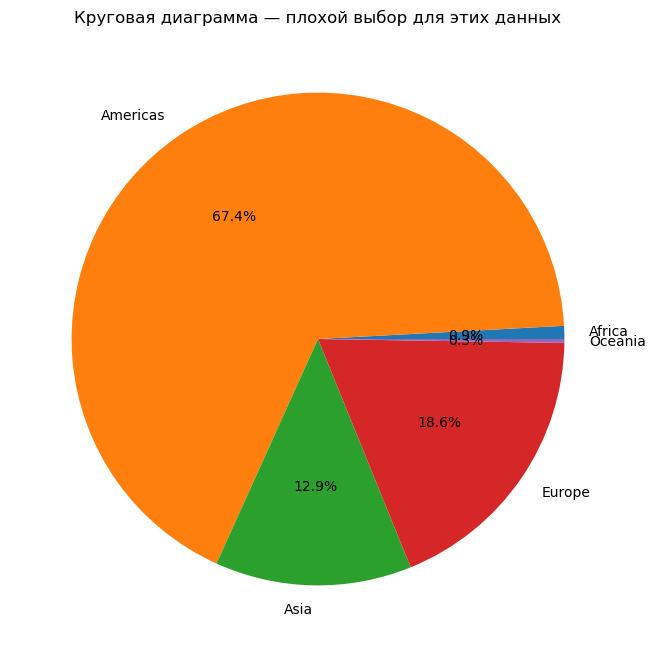

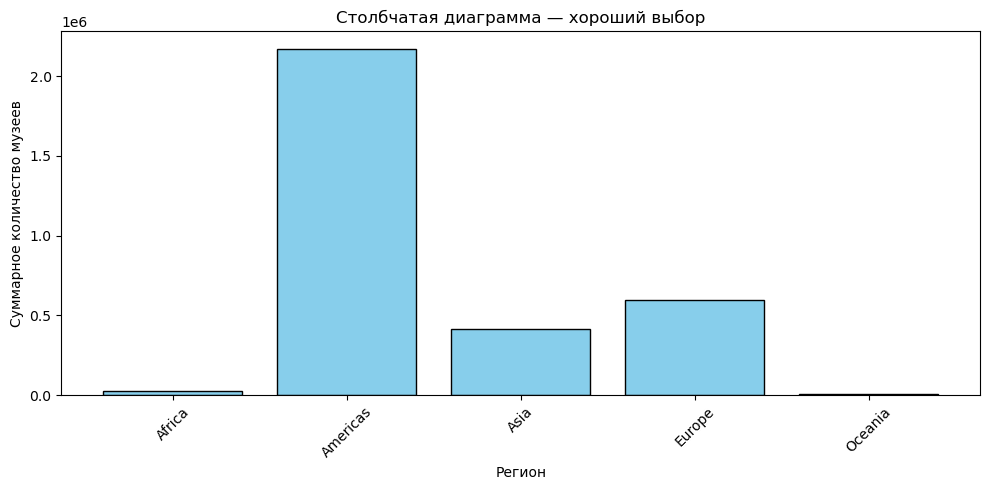

In [7]:
# Плохая визуализация (для демонстрации)
plt.figure(figsize=(8, 8))
region_totals = df.groupby('region')['total_museums'].sum()
plt.pie(region_totals, labels=region_totals.index, autopct='%1.1f%%')
plt.title('Круговая диаграмма — плохой выбор для этих данных')
plt.show()

# Хорошая визуализация
plt.figure(figsize=(10, 5))
plt.bar(region_totals.index, region_totals.values, color='skyblue', edgecolor='black')
plt.title('Столбчатая диаграмма — хороший выбор')
plt.xlabel('Регион')
plt.ylabel('Суммарное количество музеев')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Задание 8: Одна и та же информация — разные графики

Для пары признаков: `gdp_per_capita_usd` (ВВП) и `total_museums` (музеи).

**График 1: Scatter plot (точечная диаграмма)**
- Подчёркивает: индивидуальные наблюдения, выбросы, кластеры стран.
- Легко заметить: страны с высоким ВВП и низким числом музеев (или наоборот).

**График 2: Hexbin plot (шестиугольное бинирование)**
- Подчёркивает: плотность точек в областях с большим количеством данных.
- Легко заметить: где сосредоточено большинство стран (область низкого ВВП и низкого числа музеев).
- Сложно заметить: отдельные выбросы и конкретные страны.

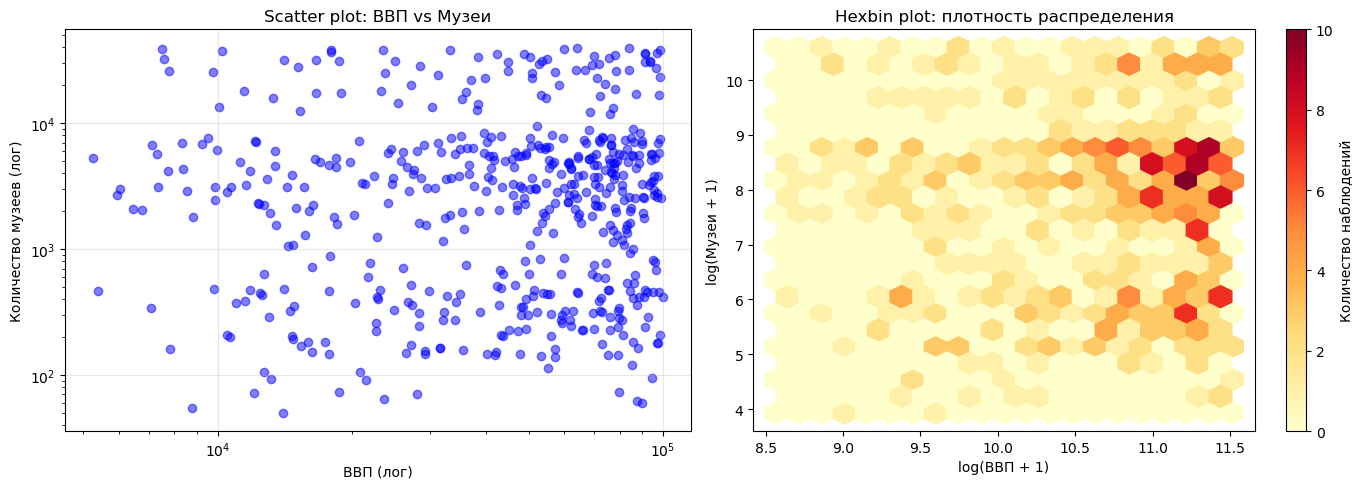

In [9]:
# Две визуализации для одной пары признаков

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Scatter plot
axes[0].scatter(df['gdp_per_capita_usd'], df['total_museums'], alpha=0.5, c='blue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Scatter plot: ВВП vs Музеи')
axes[0].set_xlabel('ВВП (лог)')
axes[0].set_ylabel('Количество музеев (лог)')
axes[0].grid(True, alpha=0.3)

# График 2: Hexbin plot (для демонстрации плотности)
hb = axes[1].hexbin(np.log1p(df['gdp_per_capita_usd']), np.log1p(df['total_museums']), gridsize=20, cmap='YlOrRd')
axes[1].set_title('Hexbin plot: плотность распределения')
axes[1].set_xlabel('log(ВВП + 1)')
axes[1].set_ylabel('log(Музеи + 1)')
plt.colorbar(hb, ax=axes[1], label='Количество наблюдений')
plt.tight_layout()
plt.show()